# 📊 Deep Research — Single Report Evaluation for the domain `Ecology`

This notebook evaluates one Deep Research `.md` report using **YESciEval rubrics**.

### Steps
1. Read the research **question from the domain CSV**
2. Load the `.md` report as plain text → passed as `answer` to YESciEval
3. Run the YESciEval judge across all rubrics
4. Aggregate rubric scores → **category scores (1–5)**
5. Display a score table and a **6-panel quality plot**
6. Save JSON + CSV outputs

---
**Prerequisites:** `pip install yescieval python-dotenv matplotlib numpy`

## 1 — Imports & Setup

In [1]:
!pip install yescieval python-dotenv matplotlib

In [2]:
import re, json, csv
from pathlib import Path
from typing import Dict, Tuple, List
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from dotenv import load_dotenv
import torch
from datetime import datetime, timezone
load_dotenv()
print("✅ Core imports loaded")

✅ Core imports loaded


/nfs/home/gillm/miniconda3/envs/py312/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [3]:
from yescieval import CustomAutoJudge, VocabularyInjector, ExampleInjector
from yescieval.rubric.pointwise.depth      import TemporalPrecision, CausalReasoning, MechanisticUnderstanding
from yescieval.rubric.pointwise.breadth    import ContextCoverage, ScopeCoverage, DimensionCoverage, ScaleCoverage, MethodCoverage
from yescieval.rubric.pointwise.rigor      import EpistemicCalibration, ExplicitUncertainty, QuantitativeEvidenceAndUncertainty
from yescieval.rubric.pointwise.innovation import StateOfTheArtAndNovelty
from yescieval.rubric.pointwise.gap        import GapIdentification
print("✅ YESciEval imports loaded")

/nfs/home/gillm/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ YESciEval imports loaded


## 2 — Configuration

Set the domain, device, judge model and max_new_tokens.

In [4]:
# --- USER CONFIGURATION ---

REPORT_PATH    = "/nfs/home/gillm/deep-research/data/ecology/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b1.md" 
QUESTIONS_CSV  = "/nfs/home/gillm/deep-research/data/ecology/49-questions-ecology.csv" 
OUTPUT_DIR     = "/nfs/home/gillm/deep-research/eval/output" 
DOMAIN         = "ecology" # nlp or ecology
MODEL_ID       = "Qwen/Qwen3-1.7B"
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")                                    
HF_TOKEN       = "your_huggingface_token_here" 
MAX_NEW_TOKENS = 2048
ALL_CONFIGS = ['d1_b1', 'd1_b4', 'd4_b1', 'd4_b4']

# Category → list of (RubricClass, weight) tuples.
CATEGORIES: Dict[str, List[Tuple[type, float]]] = {
    "depth": [
        (TemporalPrecision,         1/3),
        (CausalReasoning,           1/3),
        (MechanisticUnderstanding,  1/3),
    ],
    "breadth": [
        (ContextCoverage,   1/5),
        (ScopeCoverage,     1/5),
        (DimensionCoverage, 1/5),
        (MethodCoverage, 1/5),
        (ScaleCoverage, 1/5)
    ],
    "rigor": [
        (EpistemicCalibration, 1/3),
        (ExplicitUncertainty, 1/3),
        (QuantitativeEvidenceAndUncertainty, 1/3)
    ],
    "innovation": [
        (StateOfTheArtAndNovelty, 1.0)
    ],
    "gap": [
        (GapIdentification, 1.0),
    ],
}

RATING_MIN, RATING_MAX = 1, 5

print(f"Report : {REPORT_PATH}")
print(f"CSV    : {QUESTIONS_CSV}")
print(f"Model  : {MODEL_ID}")
print(f"Categories: {list(CATEGORIES.keys())}")

cuda
Report : /nfs/home/gillm/deep-research/data/ecology/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b1.md
CSV    : /nfs/home/gillm/deep-research/data/ecology/49-questions-ecology.csv
Model  : Qwen/Qwen3-1.7B
Categories: ['depth', 'breadth', 'rigor', 'innovation', 'gap']


## 3 — Helper Functions

In [5]:
def parse_config(stem: str) -> str:
    """Extracts dX_bY from filename e.g. 1_o3-mini_orkg_d1_b1 → d1_b1."""
    m = re.search(r'd(\d+)_b(\d+)', stem)
    return f"d{m.group(1)}_b{m.group(2)}" if m else 'd1_b1'


def parse_report_number(stem: str) -> int:
    """Extracts the leading report number from filename e.g. 1_o3-mini → 1."""
    m = re.match(r'(\d+)[_\-]', stem)
    return int(m.group(1)) if m else -1

def load_question_from_csv(csv_path: str, report_number: int) -> str:
    """
    Reads the research question by ROW POSITION (1-based) from the CSV.
    """
    encodings_to_try = ['cp1252', 'utf-8', 'utf-8-sig', 'latin-1']

    for encoding in encodings_to_try:
        try:
            with open(csv_path, newline='', encoding=encoding) as f:
                reader = csv.DictReader(f)
                for row_num, row in enumerate(reader, start=1):
                    if row_num == report_number:
                        q = row.get('Your research question.', '').strip()
                        return q if q else f'Empty question at row {report_number}'
            return f'Row {report_number} not found in CSV (file has fewer rows)'
        except UnicodeDecodeError:
            continue

    return f'Could not open CSV with any known encoding'


def parse_judge_result(result, rubric_name: str) -> Tuple[int, str]:
    """
    Extracts (rating 1-5, rationale) from a YESciEval judge result.
    Handles: raw string with optional <think> block, dict, Pydantic model.
    """
    # ── string path: strip <think> block, extract JSON ──
    if isinstance(result, str):
        cleaned = re.sub(r'<think>.*?</think>', '', result, flags=re.DOTALL).strip()
        json_str = None
        depth, start = 0, None
        for i, ch in enumerate(cleaned):
            if ch == '{':
                if depth == 0: start = i
                depth += 1
            elif ch == '}':
                depth -= 1
                if depth == 0 and start is not None:
                    json_str = cleaned[start:i+1]
                    break
        if json_str:
            try:
                result = json.loads(json_str)
            except json.JSONDecodeError:
                pass
        if isinstance(result, str):
            try: return int(result.strip()), ''
            except ValueError: return 0, result

    # ── dict path ──
    if isinstance(result, dict):
        inner = result.get(rubric_name) or result.get(rubric_name.lower())
        if inner is None and len(result) == 1:
            inner = next(iter(result.values()))
        if isinstance(inner, dict):
            return int(inner.get('rating', 0)), str(inner.get('rationale', ''))
        if 'rating' in result:
            return int(result['rating']), str(result.get('rationale', ''))
        return 0, str(result)

    # ── Pydantic / dataclass ──
    if hasattr(result, 'rating') and hasattr(result, 'rationale'):
        return int(result.rating), str(result.rationale)
    if hasattr(result, 'score'):
        try: return int(round(float(result.score))), ''
        except (ValueError, TypeError): pass
    try: return int(str(result).strip()), ''
    except ValueError: pass
    return 0, str(result)


def compute_category_score(rubric_scores: List[Tuple[float, float]]) -> float:
    """
    Weighted mean of (score, weight) pairs.
    Input scores are 1-5, output is normalized to 0.0-1.0.
    Formula: (weighted_mean - 1) / (5 - 1)
    """
    total_w = sum(w for _, w in rubric_scores)
    if not total_w:
        return 0.0
    weighted_mean = sum(s * w for s, w in rubric_scores) / total_w  # still 1-5
    return round((weighted_mean - 1) / (5 - 1), 4)                  # normalize to 0-1

print("✅ Helpers defined")

✅ Helpers defined


## 4 — Load Report & Read Question from CSV

In [6]:
report_path = Path(REPORT_PATH).resolve()
if not report_path.exists():
    raise FileNotFoundError(f'Report not found: {report_path}')

report_md   = report_path.read_text(encoding='utf-8', errors='ignore')
stem        = report_path.stem
config_str  = parse_config(stem)
report_num  = parse_report_number(stem)
question    = load_question_from_csv(QUESTIONS_CSV, report_num)

print(f"Report Name : {report_path.name}")
print(f"Config  : {config_str}")
print(f"Report Number  : {report_num}")
print(f"Research Question: {question}")

Report Name : 1_o3-mini_orkg_d1_b1.md
Config  : d1_b1
Report Number  : 1
Research Question: What is the effect of management extensification on grasslands plant diversity?


## 5 — Initialise the YESciEval Judge

In [7]:
print(f"⏳ Loading {MODEL_ID} on {DEVICE} ...")
judge = CustomAutoJudge()
judge.from_pretrained(model_id=MODEL_ID, device=DEVICE, token=HF_TOKEN or None)
print(f"✅ Judge ready")
EVAL_START_TIME = datetime.now(timezone.utc)
print(f"🕐 Evaluation start (UTC): {EVAL_START_TIME.isoformat()}")


⏳ Loading Qwen/Qwen3-1.7B on cuda ...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [00:01<00:00, 274.43it/s]
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Judge ready
🕐 Evaluation start (UTC): 2026-05-06T14:13:09.566995+00:00


## 6 — Run Evaluation

For each category, each rubric is scored independently (1–5), then the category score is the **weighted mean** of its rubric scores (still 1–5).

In [8]:
papers = {}

rubric_raw:    Dict[str, dict]  = {}   # individual rubric results
category_scores: Dict[str, float] = {} # aggregated per-category score (1-5)

for cat_name, rubric_list in CATEGORIES.items():
    print(f"\n📂 Category: {cat_name.upper()}")
    cat_rubric_scores: List[Tuple[float, float]] = []

    for RubricClass, weight in rubric_list:
        rname = RubricClass.__name__
        if rname not in rubric_raw:
            print(f"   🔎 [{rname}] (w={weight:.3f}) ...")
            rubric = RubricClass(
                papers=papers, question=question,
                answer=report_md, domain=DOMAIN,
                vocabulary=VocabularyInjector(), example=ExampleInjector(),
            )
            raw = judge.judge(rubric=rubric, max_new_tokens=MAX_NEW_TOKENS)
            rating, rationale = parse_judge_result(raw, rname)
            rubric_raw[rname] = {'rating': rating, 'rationale': rationale, 'weight_in': {}}
            print(f"      rating={rating}/5")
        else:
            print(f"   ♻️  [{rname}] reusing cached result")
            rating = rubric_raw[rname]['rating']

        rubric_raw[rname]['weight_in'][cat_name] = weight
        cat_rubric_scores.append((float(rating), weight))

    cat_score = compute_category_score(cat_rubric_scores)
    category_scores[cat_name] = cat_score
    print(f"   ✅ {cat_name} score = {cat_score:.2f}/1")

# Overall = mean of category scores (1-5)
overall_score = round(sum(category_scores.values()) / len(category_scores), 4)
print(f"\n🏁 Overall score = {overall_score:.2f}/1")


📂 Category: DEPTH
   🔎 [TemporalPrecision] (w=0.333) ...
      rating=4/5
   🔎 [CausalReasoning] (w=0.333) ...
      rating=5/5
   🔎 [MechanisticUnderstanding] (w=0.333) ...
      rating=4/5
   ✅ depth score = 0.83/1

📂 Category: BREADTH
   🔎 [ContextCoverage] (w=0.200) ...
      rating=5/5
   🔎 [ScopeCoverage] (w=0.200) ...
      rating=5/5
   🔎 [DimensionCoverage] (w=0.200) ...
      rating=0/5
   🔎 [MethodCoverage] (w=0.200) ...
      rating=5/5
   🔎 [ScaleCoverage] (w=0.200) ...
      rating=5/5
   ✅ breadth score = 0.75/1

📂 Category: RIGOR
   🔎 [EpistemicCalibration] (w=0.333) ...
      rating=4/5
   🔎 [ExplicitUncertainty] (w=0.333) ...
      rating=4/5
   🔎 [QuantitativeEvidenceAndUncertainty] (w=0.333) ...
      rating=3/5
   ✅ rigor score = 0.67/1

📂 Category: INNOVATION
   🔎 [StateOfTheArtAndNovelty] (w=1.000) ...
      rating=4/5
   ✅ innovation score = 0.75/1

📂 Category: GAP
   🔎 [GapIdentification] (w=1.000) ...
      rating=4/5
   ✅ gap score = 0.75/1

🏁 Overall score 

## 7 — Raw Rubric Scores Plot (1–5)

For each **individual rubric** (TemporalPrecision, CausalReasoning, MechanisticUnderstanding, etc.)
we plot the raw 1–5 rating the judge assigned. One panel per rubric, colour-coded by dimension.


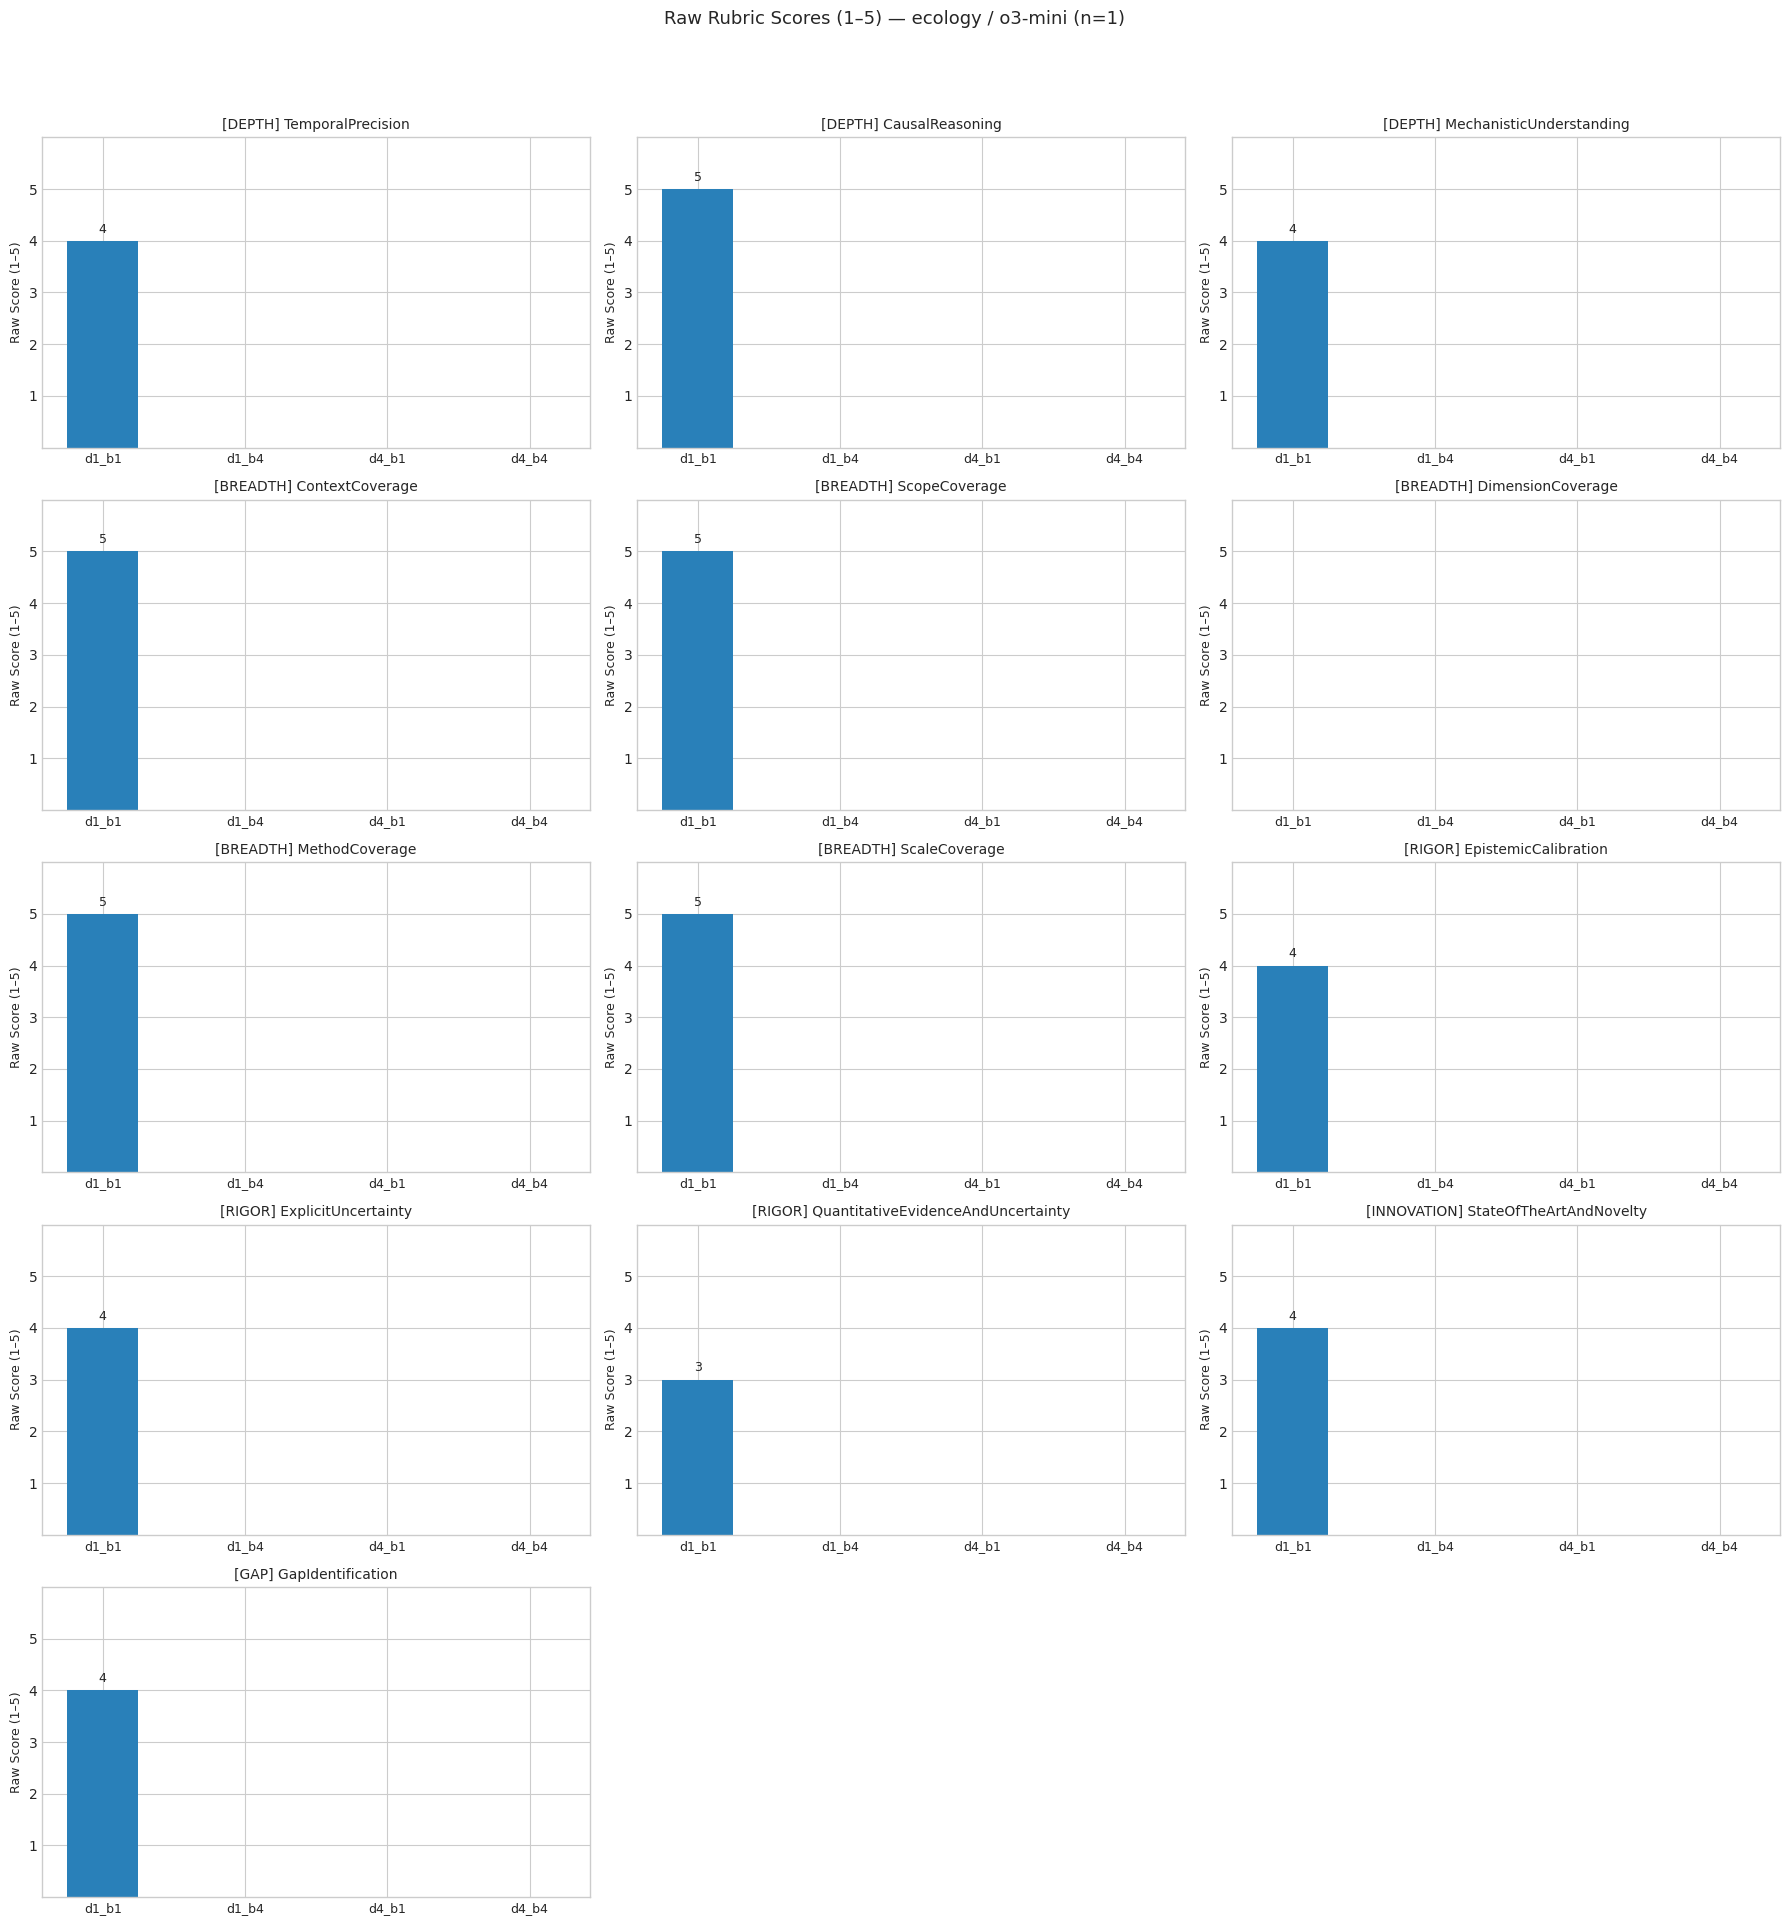

📊 Raw rubric score plot rendered


In [10]:
# ── Raw rubric scores (1–5) per rubric ───────────────────────────────────────
# One bar per rubric showing the raw 1-5 judge rating.
# Panels grouped by category/dimension

ALL_CONFIGS = ['d1_b1', 'd1_b4', 'd4_b1', 'd4_b4']  # x-axis slots 

RUBRIC_ORDER = {
    'depth':      ['TemporalPrecision', 'CausalReasoning', 'MechanisticUnderstanding'],
    'breadth':    ['ContextCoverage', 'ScopeCoverage', 'DimensionCoverage', 'MethodCoverage', 'ScaleCoverage'],
    'rigor':      ['EpistemicCalibration', 'ExplicitUncertainty', 'QuantitativeEvidenceAndUncertainty'],
    'innovation': ['StateOfTheArtAndNovelty'],
    'gap':        ['GapIdentification'],
}

RUBRIC_COLORS = {
    'depth':   '#2980b9',  
    'breadth': '#2980b9',   
    'rigor':   '#2980b9',
    'innovation': '#2980b9',
    'gap': '#2980b9'
}

ALL_RUBRICS_FLAT = [
    (cat, rname)
    for cat, rubrics in RUBRIC_ORDER.items()
    for rname in rubrics
]

n_rubrics  = len(ALL_RUBRICS_FLAT)
n_cols_rub = 3
n_rows_rub = int(np.ceil(n_rubrics / n_cols_rub))

plt.style.use('seaborn-v0_8-whitegrid')
fig_rub, axes_rub = plt.subplots(
    n_rows_rub, n_cols_rub,
    figsize=(6 * n_cols_rub, 4 * n_rows_rub),
    squeeze=False,
)
axes_rub_flat = axes_rub.ravel()

for pi, (cat, rname) in enumerate(ALL_RUBRICS_FLAT):
    ax    = axes_rub_flat[pi]
    color = RUBRIC_COLORS.get(cat, '#2980b9')
    score = rubric_raw.get(rname, {}).get('rating', 0)

    # One bar per config slot — current config gets the real score, others 0
    bar_vals = [score if cfg == config_str else 0 for cfg in ALL_CONFIGS]
    ax.bar(list(range(len(ALL_CONFIGS))), bar_vals, color=color, width=0.5)

    ax.set_title(f'[{cat.upper()}] {rname}', fontsize=10)
    ax.set_xticks(list(range(len(ALL_CONFIGS))))
    ax.set_xticklabels(ALL_CONFIGS, fontsize=9)
    ax.set_ylim(0, 6.0)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Raw Score (1–5)', fontsize=9)

    for x, v in enumerate(bar_vals):
        if v:
            ax.text(x, v + 0.1, str(v), ha='center', va='bottom', fontsize=9)

for j in range(pi + 1, len(axes_rub_flat)):
    axes_rub_flat[j].set_visible(False)

# engine_str derived here so §6b is self-contained
engine     = re.search(r'\d+_(.*?)_orkg', stem)
engine_str = engine.group(1) if engine else stem

fig_rub.suptitle(
    f'Raw Rubric Scores (1–5) — {DOMAIN} / {engine_str} (n=1)',
    fontsize=13,
)
fig_rub.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()
print('📊 Raw rubric score plot rendered')


## 8 — Quality Dimensions Plot

6-panel bar chart to display the scores for each rubric dimension. Scores are displayed on the **0-1 scale**.

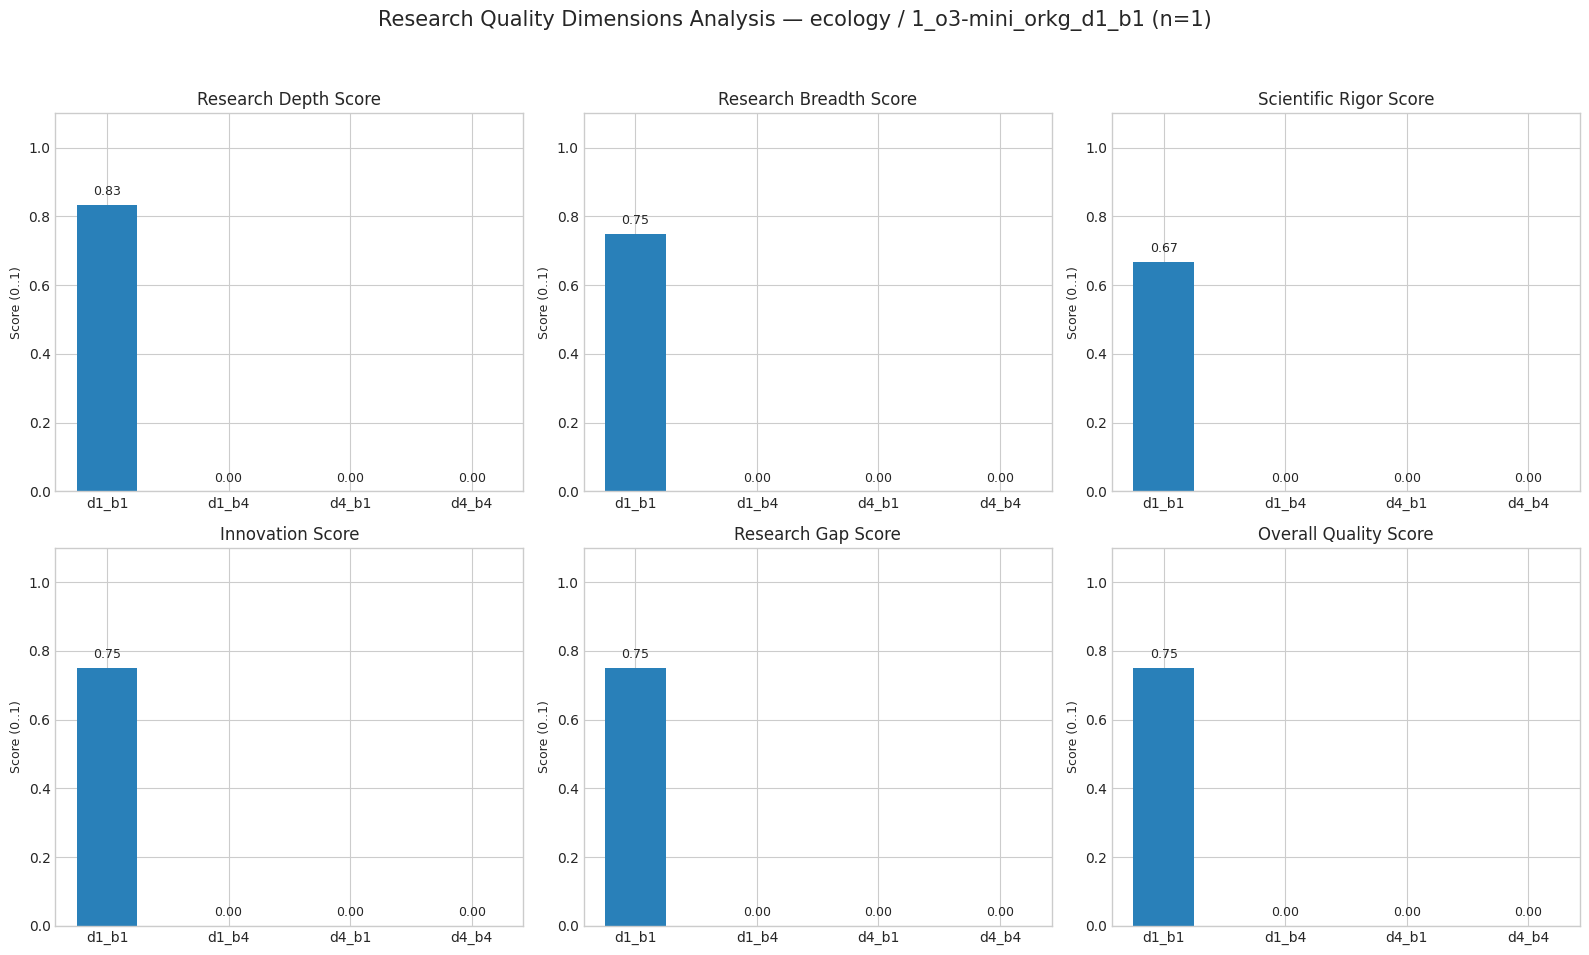

📊 Plot rendered


In [11]:
PANEL_TITLES = {
    'depth':      'Research Depth Score',
    'breadth':    'Research Breadth Score',
    'rigor':      'Scientific Rigor Score',
    'innovation': 'Innovation Score',
    'gap':        'Research Gap Score',
    'overall':    'Overall Quality Score',
}

xs = range(len(ALL_CONFIGS))

plot_scores = {k: category_scores.get(k, 0.0) for k in list(PANEL_TITLES.keys())[:-1]}
plot_scores['overall'] = overall_score

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (cat, panel_title) in enumerate(PANEL_TITLES.items()):
    ax  = axes[i]
    val = plot_scores[cat]

    # Build bar values — current config gets the real score, others get 0
    bar_vals = [val if cfg == config_str else 0.0 for cfg in ALL_CONFIGS]

    ax.bar(xs, bar_vals, color='#2980b9', width=0.5)
    ax.set_title(panel_title, fontsize=12)
    ax.set_xticks(list(xs))
    ax.set_xticklabels(ALL_CONFIGS, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score (0..1)', fontsize=9)

    # Label each bar
    for x, v in zip(xs, bar_vals):
        ax.text(x, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

engine = re.search(r'\\d+_(.*?)_orkg', stem)
engine_str = engine.group(1) if engine else stem
fig.suptitle(
    f'Research Quality Dimensions Analysis — {DOMAIN} / {engine_str} (n=1)',
    fontsize=15
)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("📊 Plot rendered")

## 9 — Final Evaluation Output (JSON)

In [12]:
final_output = {
    'report':           str(report_path),
    'report_number':    report_num,
    'config':           config_str,
    'domain':           DOMAIN,
    'question':         question,
    'model':            MODEL_ID,
    'rubric_scores':    rubric_raw,
    'category_scores':  category_scores,
    'overall':          overall_score,
}
display(Markdown('---\n### 🏁 Final Output\n---'))
print(json.dumps(final_output, indent=2, ensure_ascii=False))

---
### 🏁 Final Output
---

{
  "report": "/nfs/home/gillm/deep-research/data/ecology/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b1.md",
  "report_number": 1,
  "config": "d1_b1",
  "domain": "ecology",
  "question": "What is the effect of management extensification on grasslands plant diversity?",
  "model": "Qwen/Qwen3-1.7B",
  "rubric_scores": {
    "TemporalPrecision": {
      "rating": 4,
      "rationale": "The response includes specific temporal references such as 'longitudinal studies over the past three decades' and 'European long-term experiments,' but relies on vague terms like 'historically' and 'long-term' in other contexts. Specific bounded time expressions (e.g., 'past three decades,' 'longitudinal studies') are present, though some temporal markers remain general.",
      "weight_in": {
        "depth": 0.3333333333333333
      }
    },
    "CausalReasoning": {
      "rating": 5,
      "rationale": "The response demonstrates strong causal reasoning throughout, explicitly linking management practic

## 10 — Save Raw Model Outputs to Disk

Saves a timestamped JSON file containing:
- All raw rubric ratings and rationales
- Evaluation **start/end timestamps** (UTC)
- The **model** used for evaluation
- The **domain**, config, and research question

File name pattern: `raw_output_{DOMAIN}_{model_slug}_{timestamp}.json`


In [15]:
# ── Save raw rubric outputs (ratings + rationales) to a timestamped JSON ────
# EVAL_START_TIME captured right after judge init (§5).
if 'EVAL_START_TIME' not in dir():
    EVAL_START_TIME = datetime.now(timezone.utc)

EVAL_END_TIME = datetime.now(timezone.utc)

model_slug    = MODEL_ID.replace('/', '--').replace(' ', '_')
judge_id      = getattr(judge, 'model_id', MODEL_ID)
timestamp_str = EVAL_END_TIME.strftime('%Y%m%d_%H%M%S')

raw_output_doc = {
    'meta': {
        'domain':          DOMAIN,
        'report':          str(report_path),
        'report_number':   report_num,
        'config':          config_str,
        'question':        question,
        'model':           MODEL_ID,
        'eval_start_utc':  EVAL_START_TIME.isoformat(),
        'eval_end_utc':    EVAL_END_TIME.isoformat(),
        'eval_duration_s': round((EVAL_END_TIME - EVAL_START_TIME).total_seconds(), 1)
    },
    'raw_rubric_outputs': {
        rname: {
            'rating':    rdata['rating'],
            'rationale': rdata['rationale'],
        }
        for rname, rdata in rubric_raw.items()
    },
}

raw_out_path = Path(OUTPUT_DIR) / f'raw_output_{DOMAIN}_{model_slug}_{timestamp_str}.json'
raw_out_path.write_text(
    json.dumps(raw_output_doc, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

rub_fig_path = Path(OUTPUT_DIR) / f'{stem}_raw_rubric_scores.png'
fig_rub.savefig(rub_fig_path, dpi=200, bbox_inches='tight')

print(f'💾 Raw output JSON  → {raw_out_path}')
print(f'💾 Rubric plot      → {rub_fig_path}')
print(f'   Model   : {MODEL_ID}')
print(f'   Start   : {EVAL_START_TIME.isoformat()}')
print(f'   End     : {EVAL_END_TIME.isoformat()}')
print(f'   Duration: {raw_output_doc["meta"]["eval_duration_s"]} s')
print()
display(Markdown('---\n### 🗂️ Raw Output Meta Preview\n---'))
print(json.dumps(raw_output_doc['meta'], indent=2))


💾 Raw output JSON  → /nfs/home/gillm/deep-research/eval/output/raw_output_ecology_Qwen--Qwen3-1.7B_20260506_141810.json
💾 Rubric plot      → /nfs/home/gillm/deep-research/eval/output/1_o3-mini_orkg_d1_b1_raw_rubric_scores.png
   Model   : Qwen/Qwen3-1.7B
   Start   : 2026-05-06T14:13:09.566995+00:00
   End     : 2026-05-06T14:18:10.743134+00:00
   Duration: 301.2 s



---
### 🗂️ Raw Output Meta Preview
---

{
  "domain": "ecology",
  "report": "/nfs/home/gillm/deep-research/data/ecology/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b1.md",
  "report_number": 1,
  "config": "d1_b1",
  "question": "What is the effect of management extensification on grasslands plant diversity?",
  "model": "Qwen/Qwen3-1.7B",
  "eval_start_utc": "2026-05-06T14:13:09.566995+00:00",
  "eval_end_utc": "2026-05-06T14:18:10.743134+00:00",
  "eval_duration_s": 301.2
}
